In [1]:
import gymnasium as gym
import random
import numpy as np
import math
from gymnasium import spaces
import matplotlib.pyplot as plt

In [2]:
class MultiArmedBanditEnv(gym.Env):
    def __init__(self, n_arms, means, stds):
        super(MultiArmedBanditEnv, self).__init__()
        self.n_arms = n_arms  # Number of arms
        self.means = means  # True means of an arm (unknown to the agent)
        self.stds = stds  # Standard deviations for the arms' rewards
        self.action_space = spaces.Discrete(self.n_arms)  # Discrete action space
        self.observation_space = spaces.Discrete(1)  # No real observation space

    def reset(self):
        # Reset the environment; no state variables to reset here
        return 0

    def step(self, action):
        # Sample a reward from the chosen arm
        reward = np.random.normal(self.means[action], self.stds[action])
        return 0, reward, True, {}  # No state, done is True, no info

In [3]:
class GreedyAgent:
    def __init__(self, n_arms):
        self.q_values = [0.0] * n_arms  # Estimated values for each arm
        self.n_pulls = [0] * n_arms  # Number of pulls for each arm
        self.total_rewards = []  # To track total rewards over time
        self.q_values_history = []  # To track q-values over time
        self.selection_counts = [0] * n_arms  # Track how many times each arm is selected

    def select_action(self):
        # Select the arm with the highest estimated value
        return self.q_values.index(max(self.q_values))

    def update(self, action, reward):
        # Increment the selection count for the chosen arm
        self.selection_counts[action] += 1
        # Incremental mean update for the Q-values
        self.n_pulls[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.n_pulls[action]
        self.total_rewards.append(reward)
        self.q_values_history.append(self.q_values.copy())

In [4]:
class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.q_values = [0.0] * n_arms  # Estimated values for each arm
        self.n_pulls = [0] * n_arms  # Number of pulls for each arm
        self.epsilon = epsilon
        self.total_rewards = []  # To track total rewards over time
        self.q_values_history = []  # To track q-values over time
        self.selection_counts = [0] * n_arms  # Track how many times each arm is selected

    def select_action(self):
        if random.random() < self.epsilon:
            # Explore randomly
            return random.randint(0, self.n_arms - 1)
        else:
            # Exploit the best-known arm
            return self.q_values.index(max(self.q_values))

    def update(self, action, reward):
        # Increment the selection count for the chosen arm
        self.selection_counts[action] += 1
        # Incremental mean update for the Q-values
        self.n_pulls[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.n_pulls[action]
        self.total_rewards.append(reward)
        self.q_values_history.append(self.q_values.copy())

In [5]:
class UCB1Agent:
    def __init__(self, n_arms, c=2):
        self.n_arms = n_arms
        self.q_values = [0.0] * n_arms  # Estimated values for each arm
        self.n_pulls = [0] * n_arms  # Number of pulls for each arm
        self.total_rewards = []  # To track total rewards over time
        self.q_values_history = []  # To track q-values over time
        self.selection_counts = [0] * n_arms  # Track how many times each arm is selected
        self.c = c  # Constant to control exploration

    def select_action(self):
        total_steps = sum(self.n_pulls)
        if total_steps == 0:
            return random.randint(0, self.n_arms - 1)  # Choose randomly at the start
        ucb_values = [
            self.q_values[i] + self.c * np.sqrt(np.log(total_steps) / (self.n_pulls[i] + 1e-5))
            for i in range(self.n_arms)
        ]
        return np.argmax(ucb_values)

    def update(self, action, reward):
        # Increment the selection count for the chosen arm
        self.selection_counts[action] += 1
        # Incremental mean update for the Q-values
        self.n_pulls[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.n_pulls[action]
        self.total_rewards.append(reward)
        self.q_values_history.append(self.q_values.copy())

In [6]:
class ThompsonSamplingAgent:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.q_values = [0.0] * n_arms  # Estimated values for each arm
        self.alpha = [1] * n_arms  # Beta distribution alpha
        self.beta = [1] * n_arms  # Beta distribution beta
        self.total_rewards = []  # To track total rewards over time
        self.q_values_history = []  # To track q-values over time
        self.selection_counts = [0] * n_arms  # Track how many times each arm is selected

    def select_action(self):
        # Sample from Beta distribution for each arm
        samples = [np.random.beta(self.alpha[i], self.beta[i]) for i in range(self.n_arms)]
        return np.argmax(samples)  # Return arm with the highest sampled value

    def update(self, action, reward):
        # Increment the selection count for the chosen arm
        self.selection_counts[action] += 1
        # Update the Beta distribution parameters based on the reward
        if reward > self.q_values[action]:
            self.alpha[action] += 1  # Reward > estimated value
        else:
            self.beta[action] += 1  # Reward <= estimated value
        self.total_rewards.append(reward)
        self.q_values_history.append(self.q_values.copy())

In [7]:
# Set up the multi-armed bandit environment
n_arms = 5  # Number of arms
means = [1.0, 1.5, 2.0, 2.5, 3.0]  # The true means (unknown to agent)
stds = [1.0, 1.0, 1.0, 1.0, 1.0]  # Standard deviations for reward

env = MultiArmedBanditEnv(n_arms=n_arms, means=means, stds=stds)

# Instantiate agents
greedy_agent = GreedyAgent(n_arms)
epsilon_greedy_agent = EpsilonGreedyAgent(n_arms)
ucb_agent = UCB1Agent(n_arms)
thompson_sampling_agent = ThompsonSamplingAgent(n_arms)

In [8]:
# Run the agents and track the rewards and q-values over time
def run_agent_with_tracking(agent, env):
    total_reward = 0
    for _ in range(1000):  # Set number of iterations to 1000
        action = agent.select_action()  # Select an action
        _, reward, _, _ = env.step(action)  # Take the step
        agent.update(action, reward)  # Update the agent's knowledge
        total_reward += reward
    return total_reward, agent.total_rewards, agent.q_values_history

# Run each agent
greedy_total_reward, greedy_rewards, greedy_q_values = run_agent_with_tracking(greedy_agent, env)
epsilon_greedy_total_reward, epsilon_greedy_rewards, epsilon_greedy_q_values = run_agent_with_tracking(epsilon_greedy_agent, env)
ucb_total_reward, ucb_rewards, ucb_q_values = run_agent_with_tracking(ucb_agent, env)
thompson_total_reward, thompson_rewards, thompson_q_values = run_agent_with_tracking(thompson_sampling_agent, env)

greedy_selection_counts = greedy_agent.selection_counts
epsilon_greedy_selection_counts = epsilon_greedy_agent.selection_counts
ucb_selection_counts = ucb_agent.selection_counts
thompson_selection_counts = thompson_sampling_agent.selection_counts

print(f"Greedy Agent Total Reward: {greedy_total_reward}")
print(f"Epsilon-Greedy Agent Total Reward: {epsilon_greedy_total_reward}")
print(f"UCB1 Agent Total Reward: {ucb_total_reward}")
print(f"Thompson Sampling Agent Total Reward: {thompson_total_reward}")

Greedy Agent Total Reward: 990.3709331097822
Epsilon-Greedy Agent Total Reward: 2710.390507972439
UCB1 Agent Total Reward: 3032.774143252228
Thompson Sampling Agent Total Reward: 2377.905003998159


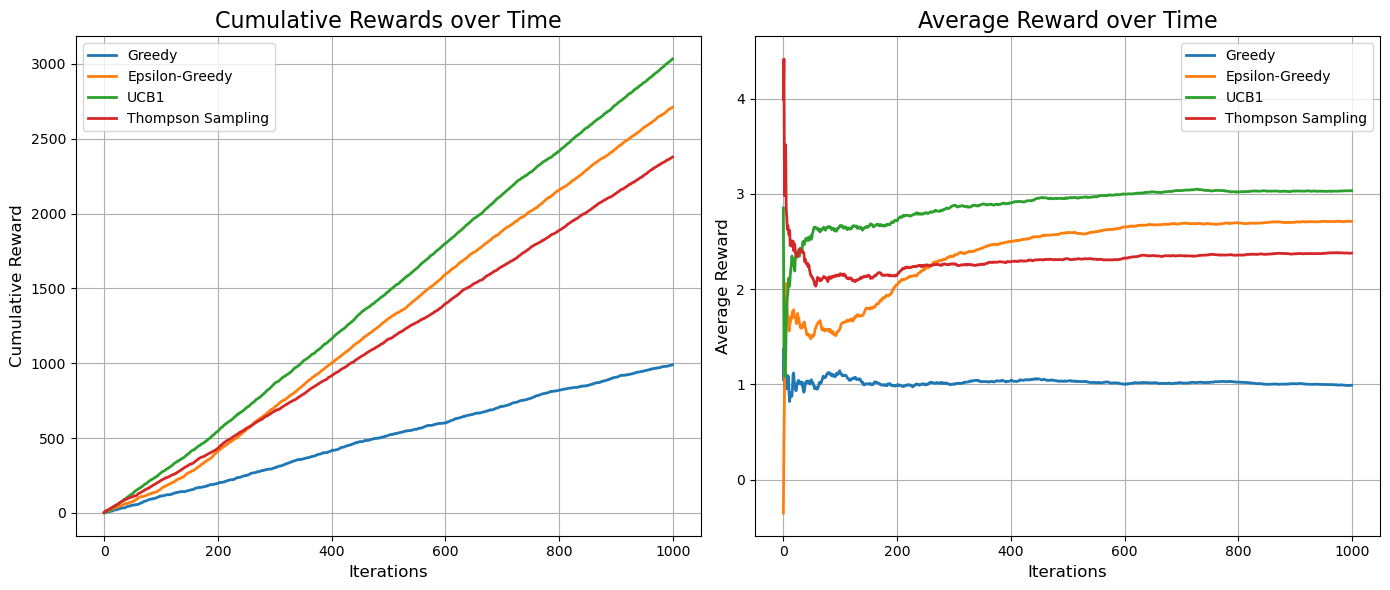

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Total Rewards function
def plot_total_rewards(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, ax):
    # Plot Cumulative Rewards for each agent
    ax.plot(np.cumsum(greedy_rewards), label='Greedy', linewidth=2)
    ax.plot(np.cumsum(epsilon_greedy_rewards), label='Epsilon-Greedy', linewidth=2)
    ax.plot(np.cumsum(ucb_rewards), label='UCB1', linewidth=2)
    ax.plot(np.cumsum(thompson_rewards), label='Thompson Sampling', linewidth=2)

    ax.set_title('Cumulative Rewards over Time', fontsize=16)
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Cumulative Reward', fontsize=12)
    ax.legend()
    ax.grid(True)

# Average Rewards function
def plot_average_rewards(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, ax):
    # Plot average reward for each agent
    ax.plot(np.cumsum(greedy_rewards) / (np.arange(1, len(greedy_rewards) + 1)), label='Greedy', linewidth=2)
    ax.plot(np.cumsum(epsilon_greedy_rewards) / (np.arange(1, len(epsilon_greedy_rewards) + 1)), label='Epsilon-Greedy', linewidth=2)
    ax.plot(np.cumsum(ucb_rewards) / (np.arange(1, len(ucb_rewards) + 1)), label='UCB1', linewidth=2)
    ax.plot(np.cumsum(thompson_rewards) / (np.arange(1, len(thompson_rewards) + 1)), label='Thompson Sampling', linewidth=2)

    ax.set_title('Average Reward over Time', fontsize=16)
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Average Reward', fontsize=12)
    ax.legend()
    ax.grid(True)

# Main function to plot both total and average rewards side by side
def plot_rewards(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
    
    plot_total_rewards(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, axs[0])
    plot_average_rewards(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, axs[1])
    
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Call the function to plot both cumulative and average rewards
plot_rewards(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards)

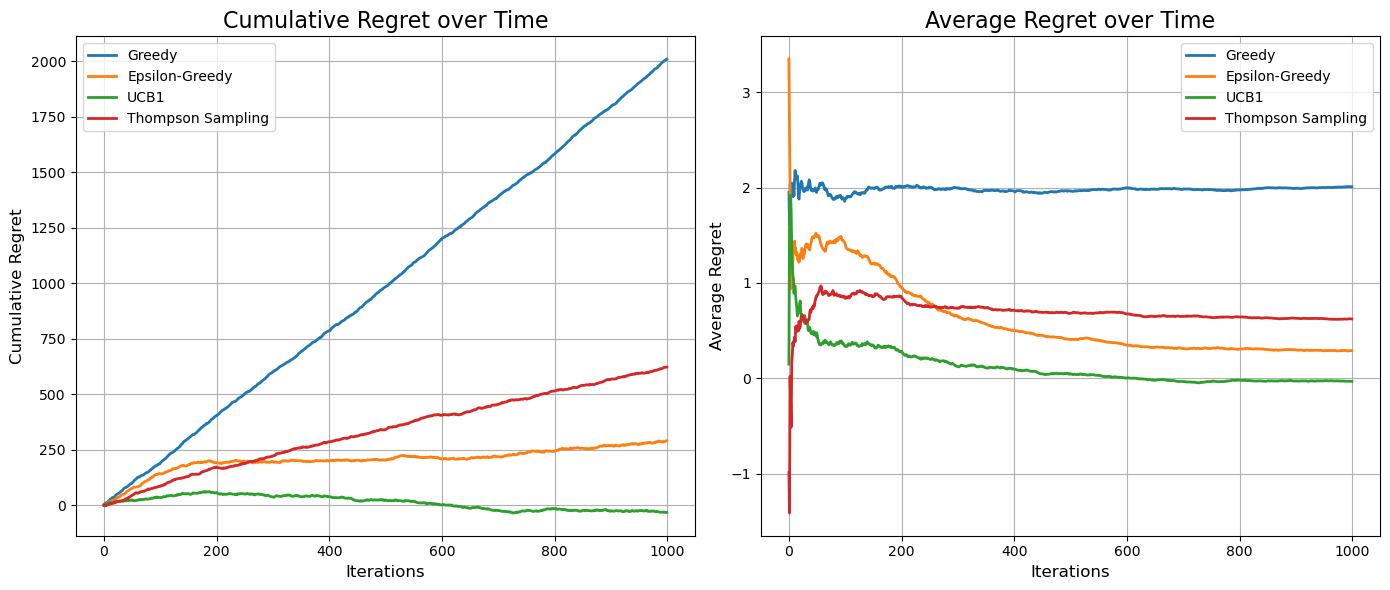

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# Cumulative Regret function
def plot_total_regret(optimal_reward, greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, ax):
    optimal_total_reward = optimal_reward * np.arange(1, len(greedy_rewards) + 1)

    # Plot Cumulative Regret for each agent
    ax.plot(optimal_total_reward - np.cumsum(greedy_rewards), label='Greedy', linewidth=2)
    ax.plot(optimal_total_reward - np.cumsum(epsilon_greedy_rewards), label='Epsilon-Greedy', linewidth=2)
    ax.plot(optimal_total_reward - np.cumsum(ucb_rewards), label='UCB1', linewidth=2)
    ax.plot(optimal_total_reward - np.cumsum(thompson_rewards), label='Thompson Sampling', linewidth=2)

    ax.set_title('Cumulative Regret over Time', fontsize=16)
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Cumulative Regret', fontsize=12)
    ax.legend()
    ax.grid(True)

# Average Regret function
def plot_average_regret(optimal_reward, greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, ax):
    # Calculate cumulative regret for each agent
    cumulative_greedy_regret = optimal_reward * np.arange(1, len(greedy_rewards) + 1) - np.cumsum(greedy_rewards)
    cumulative_epsilon_greedy_regret = optimal_reward * np.arange(1, len(epsilon_greedy_rewards) + 1) - np.cumsum(epsilon_greedy_rewards)
    cumulative_ucb_regret = optimal_reward * np.arange(1, len(ucb_rewards) + 1) - np.cumsum(ucb_rewards)
    cumulative_thompson_regret = optimal_reward * np.arange(1, len(thompson_rewards) + 1) - np.cumsum(thompson_rewards)

    # Plot Average Regret for each agent
    ax.plot(cumulative_greedy_regret / np.arange(1, len(greedy_rewards) + 1), label='Greedy', linewidth=2)
    ax.plot(cumulative_epsilon_greedy_regret / np.arange(1, len(epsilon_greedy_rewards) + 1), label='Epsilon-Greedy', linewidth=2)
    ax.plot(cumulative_ucb_regret / np.arange(1, len(ucb_rewards) + 1), label='UCB1', linewidth=2)
    ax.plot(cumulative_thompson_regret / np.arange(1, len(thompson_rewards) + 1), label='Thompson Sampling', linewidth=2)
    
    ax.set_title('Average Regret over Time', fontsize=16)
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Average Regret', fontsize=12)
    ax.legend()
    ax.grid(True)

# Main function to plot both graphs side by side
def plot_regret(optimal_reward, greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
    
    plot_total_regret(optimal_reward, greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, axs[0])
    plot_average_regret(optimal_reward, greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards, axs[1])
    
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Call the function to plot both cumulative and average regret
plot_regret(3.0, greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards)

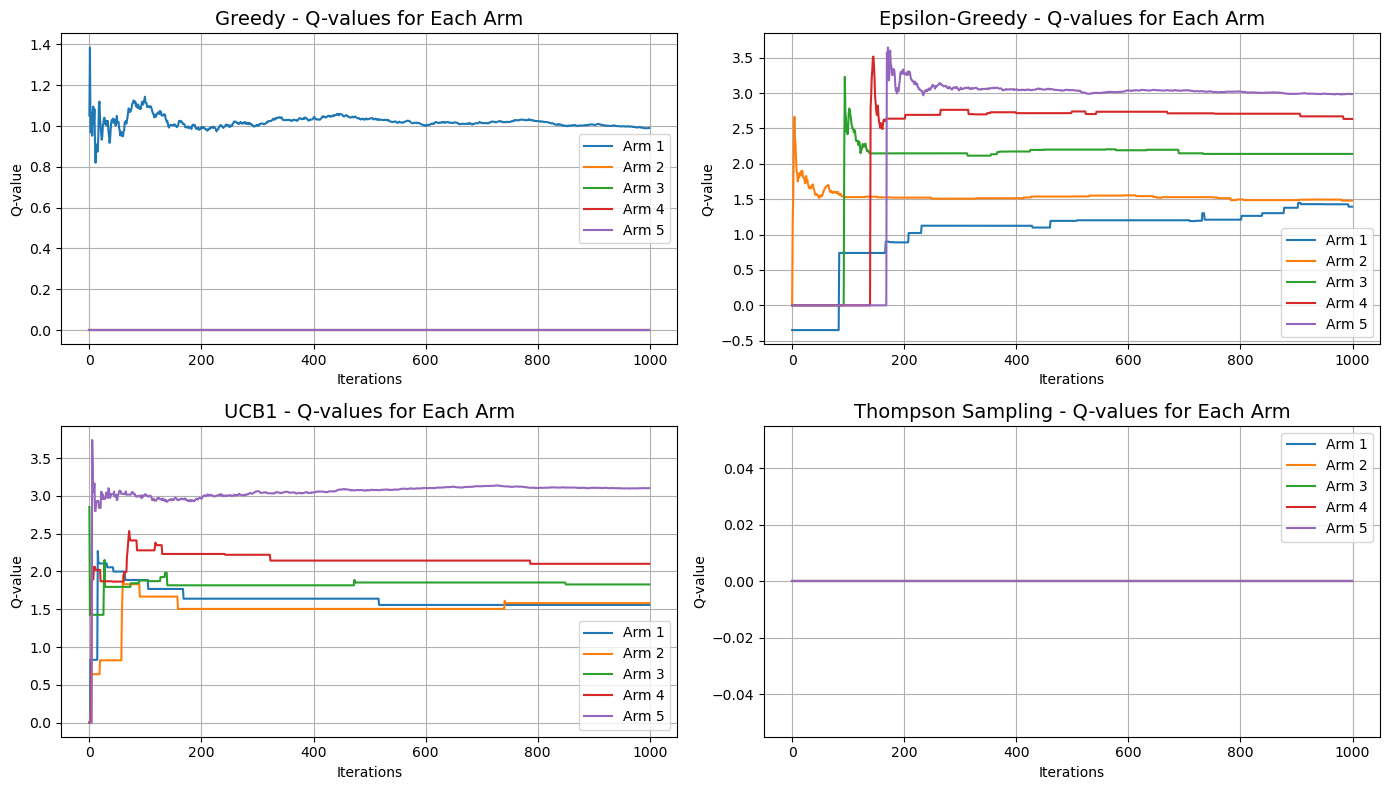

In [11]:
# Plot Q-values for each arm (for each agent)
def plot_q_values(greedy_q_values, epsilon_greedy_q_values, ucb_q_values, thompson_q_values, n_arms):
    plt.figure(figsize=(14, 8))
    
    # Plot Q-values for Greedy agent
    plt.subplot(2, 2, 1)
    for i in range(n_arms):
        plt.plot([q[i] for q in greedy_q_values], label=f'Arm {i+1}')
    plt.title('Greedy - Q-values for Each Arm', fontsize=14)
    plt.xlabel('Iterations')
    plt.ylabel('Q-value')
    plt.legend()
    plt.grid(True)

    # Plot Q-values for Epsilon-Greedy agent
    plt.subplot(2, 2, 2)
    for i in range(n_arms):
        plt.plot([q[i] for q in epsilon_greedy_q_values], label=f'Arm {i+1}')
    plt.title('Epsilon-Greedy - Q-values for Each Arm', fontsize=14)
    plt.xlabel('Iterations')
    plt.ylabel('Q-value')
    plt.legend()
    plt.grid(True)
    
    # Plot Q-values for UCB1 agent
    plt.subplot(2, 2, 3)
    for i in range(n_arms):
        plt.plot([q[i] for q in ucb_q_values], label=f'Arm {i+1}')
    plt.title('UCB1 - Q-values for Each Arm', fontsize=14)
    plt.xlabel('Iterations')
    plt.ylabel('Q-value')
    plt.legend()
    plt.grid(True)

    # Plot Q-values for Thompson Sampling agent
    plt.subplot(2, 2, 4)
    for i in range(n_arms):
        plt.plot([q[i] for q in thompson_q_values], label=f'Arm {i+1}')
    plt.title('Thompson Sampling - Q-values for Each Arm', fontsize=14)
    plt.xlabel('Iterations')
    plt.ylabel('Q-value')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_q_values(greedy_q_values, epsilon_greedy_q_values, ucb_q_values, thompson_q_values, n_arms)

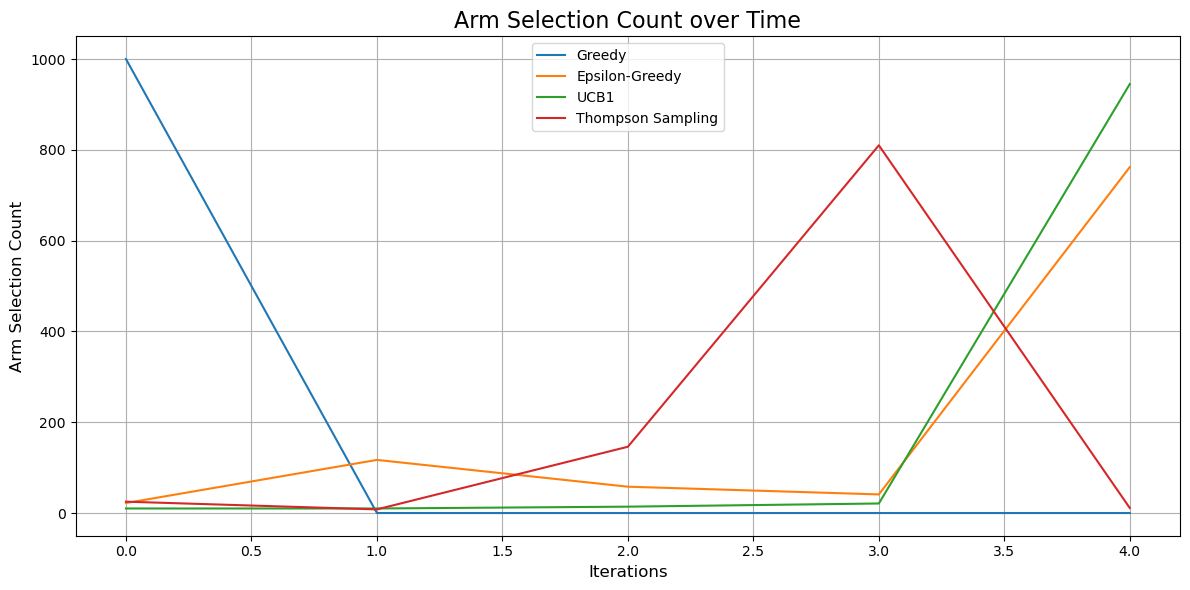

In [26]:
def plot_arm_selection_counts(greedy_selection_counts, epsilon_greedy_selection_counts, ucb_selection_counts, thompson_selection_counts):
    plt.figure(figsize=(12, 6))
    plt.plot(greedy_selection_counts, label='Greedy')
    plt.plot(epsilon_greedy_selection_counts, label='Epsilon-Greedy')
    plt.plot(ucb_selection_counts, label='UCB1')
    plt.plot(thompson_selection_counts, label='Thompson Sampling')
    
    plt.title('Arm Selection Count over Time', fontsize=16)
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Arm Selection Count', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
# Plot arm selection counts (Exploration vs Exploitation)
plot_arm_selection_counts(
    greedy_selection_counts, epsilon_greedy_selection_counts, ucb_selection_counts, thompson_selection_counts
)

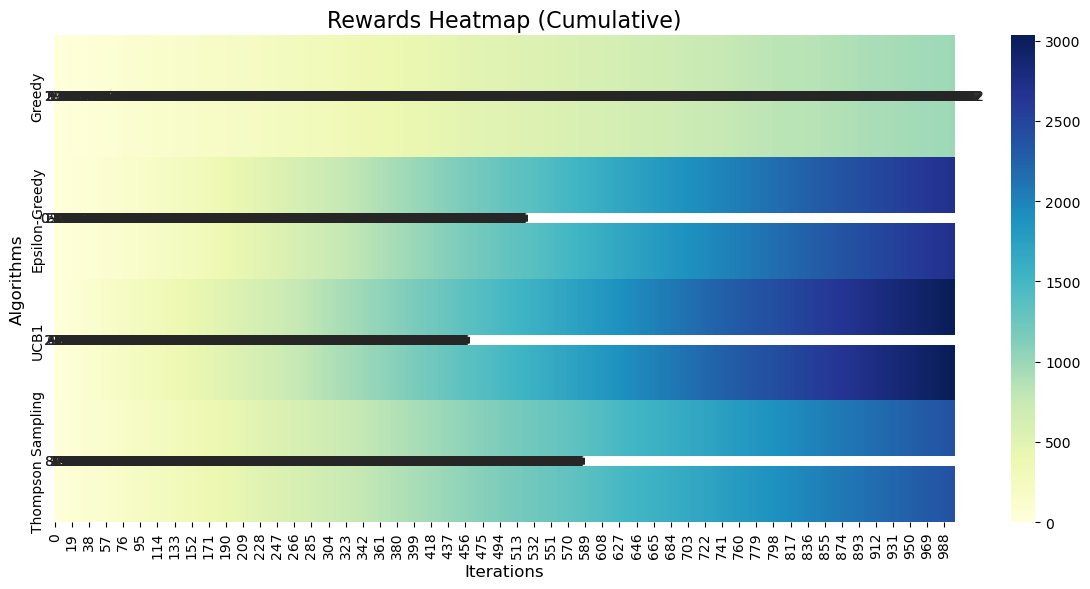

In [104]:
import seaborn as sns

def plot_reward_heatmap(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards):
    # Create a matrix of rewards for each algorithm
    rewards_matrix = np.array([np.cumsum(greedy_rewards), np.cumsum(epsilon_greedy_rewards), 
                              np.cumsum(ucb_rewards), np.cumsum(thompson_rewards)])
    
    # Plot heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(rewards_matrix, cmap='YlGnBu', annot=True, yticklabels=['Greedy', 'Epsilon-Greedy', 'UCB1', 'Thompson Sampling'])

    plt.title('Rewards Heatmap (Cumulative)', fontsize=16)
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Algorithms', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_reward_heatmap(greedy_rewards, epsilon_greedy_rewards, ucb_rewards, thompson_rewards)